# Well Production Performance Analytics for Oil & Gas Operations
### A Data Management & Analytics Case Study Using the Volve Field Open Dataset

**Course:** STQD6324 Data Management — Semester 2, 2025/2026

**Tools used:** Apache Hive (data management / ETL layer) + Python via Google Colab (analytics & visualization layer)

**Student Name:** SOFIA ANNISA BINTI JAIRI

**Matric No.:** P162501

---


## 1. Introduction & Industry Context

**Target industry: Upstream Oil & Gas / Energy Production Analytics.**

Oil and gas remains one of the largest consumers of data analytics talent in Malaysia and the wider region, with national and multinational operators (e.g. PETRONAS and its digital arm, along with oilfield service providers such as SLB and Baker Hughes) investing heavily in production surveillance, predictive maintenance and reservoir analytics teams. This makes upstream production analytics a realistic and relevant target domain for a graduating Data Science and Analytics student.

**Problem statement.** Mature oil fields generate continuous streams of well-level sensor and volumetric data (pressures, temperatures, choke settings, and oil/gas/water volumes). Operators need to continuously answer questions such as: *Which wells are underperforming? How much production is being lost to downtime? Which wells are approaching water breakthrough and need intervention?* Answering these questions at scale requires a proper data management pipeline (ingestion, cleaning, structured storage) feeding into an analytics layer — exactly the workflow this project demonstrates.

**Objectives of this project:**
1. Acquire and understand a real, open, well-level oil & gas production dataset.
2. Use **Apache Hive** as the data management / ETL layer to ingest, clean and aggregate the raw daily records.
3. Use **Python (pandas, matplotlib/seaborn, Plotly)** in Google Colab as the analytics layer to explore, visualise and interpret the cleaned data.
4. Translate the findings into actionable, production-engineering recommendations.


## 2. Dataset Overview & Source

**Source:** The dataset is drawn from the **Volve field** production data, released publicly by **Equinor** (formerly Statoil) in 2018 under the Equinor Open Data Licence for research, study and innovation purposes. Volve is a now-decommissioned field in the Norwegian North Sea that was in production from 2008 to 2016; Equinor disclosed the full subsurface and operating dataset for the field, making it one of the most widely used open datasets in petroleum data science.

**Where to get it:**
- **Primary source:** Equinor's data-sharing page — https://www.equinor.com/energy/volve-data-sharing (also indexed on Equinor's open data portal, https://data.equinor.com/). The full release (~40,000 files: production data, well logs, seismic, reservoir models, etc.) is distributed from there under the Equinor Open Data Licence.
- **File used in this notebook:** `Original_Data.csv` is the well-bore-level daily production/injection table extracted from that release (originally shipped inside `Volve production data.xlsx`, sheet "Daily Production Data"). This flat-CSV form is the version most commonly redistributed in public Volve teaching/EDA projects (e.g. on Kaggle, search "Volve production data" or "Volve well production"), and is the exact file used throughout this notebook. If accessing Equinor's own release directly, the same columns can be exported from the daily-production sheet of `Volve production data.xlsx`.
- **Licence note:** the data may not be resold and is provided "as is" for research/study purposes — see the source page for full terms before any commercial use.

**File used:** `Original_Data.csv` — a well-bore-level daily production/injection table.

**Structure:** 15,634 daily records across **24 columns** and **7 well bores** on the VOLVE field, produced via the Mærsk Inspirer platform, spanning **September 2007 to December 2016**.

**Data dictionary (key columns):**

| Column | Description |
|---|---|
| `DATEPRD` | Production/injection date |
| `NPD_WELL_BORE_NAME` | Well identifier (7 unique wells) |
| `WELL_TYPE` | `OP` = oil producer, `WI` = water injector (a few wells change role over their life) |
| `FLOW_KIND` | `production` or `injection` record |
| `ON_STREAM_HRS` | Hours the well was online that day (0–24) |
| `AVG_DOWNHOLE_PRESSURE` / `AVG_DOWNHOLE_TEMPERATURE` | Downhole sensor readings |
| `AVG_CHOKE_SIZE_P` | Average choke opening (%) |
| `AVG_WHP_P` / `AVG_WHT_P` | Wellhead pressure / temperature |
| `BORE_OIL_VOL` / `BORE_GAS_VOL` / `BORE_WAT_VOL` | Daily oil / gas / water volumes produced |
| `BORE_WI_VOL` | Daily water volume injected |

**Why this dataset fits the assignment well:** It is large enough (15k+ rows), genuinely messy (legitimate structural missingness, a few negative correction values, a daylight-saving-time artefact — see Section 4), and complex enough to require a real ETL step before meaningful analytics, which justifies the Hive + Python two-layer pipeline used throughout this notebook.


## 3. Environment & Tools Setup

As required by the assignment, this project combines **Apache Hive** (data management/ETL) with **Python via Google Colab** (analytics/visualization).

> **Important — run this section in Google Colab, not locally.** Colab gives you a fresh Ubuntu VM with full internet access, which is needed to download Hadoop and Hive. The cells below install a lightweight, single-machine Hadoop + Hive setup running in **local mode** (no real HDFS/YARN cluster is needed for a dataset this size — Hive uses the local filesystem directly). The first run of this section takes roughly 5–10 minutes; you only need to run it once per Colab session.


In [ ]:
# 3.1 Install Java (required by both Hadoop and Hive)
# Hive 3.1.3 is known to have compatibility issues with Java 11 due to changes in classloaders.
# Reverting to Java 8, which is fully compatible with Hive 3.1.3, to resolve ClassCastException.
!apt-get install -y openjdk-8-jdk -qq > /dev/null

import os
# Try java-8 first for Hive compatibility, fall back to Java 11 if 8 is not available
for jh in [
    "/usr/lib/jvm/java-8-openjdk-amd64", # Common path for OpenJDK 8
    "/usr/lib/jvm/java-11-openjdk-amd64",
    "/usr/lib/jvm/java-11-amazon-corretto",
    "/usr/lib/jvm/temurin-11-amd64"
]:
    if os.path.exists(jh):
        os.environ["JAVA_HOME"] = jh
        break
else:
    raise RuntimeError("No supported JAVA_HOME found after apt-get install. Re-run this cell.")

os.environ["PATH"] = os.environ["JAVA_HOME"] + "/bin:" + os.environ["PATH"]
print("Java home set to:", os.environ["JAVA_HOME"])
!java -version

Java home set to: /usr/lib/jvm/java-8-openjdk-amd64
openjdk version "1.8.0_492"
OpenJDK Runtime Environment (build 1.8.0_492-8u492-ga~us2-0ubuntu1~22.04.1-b09)
OpenJDK 64-Bit Server VM (build 25.492-b09, mixed mode)


In [ ]:
import os
import shutil # Import shutil for rmtree
import glob # Import glob for robust Hadoop installation check
import re # Import re for regex operations

hadoop_home = "/content/hadoop-3.3.6"
hadoop_env_path = f"{hadoop_home}/etc/hadoop/hadoop-env.sh" # Define early
hadoop_guava_glob_path = f"{hadoop_home}/share/hadoop/common/lib/guava-*.jar" # Define path to check for guava jar

# Check if Hadoop needs to be downloaded and extracted
# It needs to be extracted if:
# 1. The main directory doesn't exist, OR
# 2. The main directory exists but a critical file like hadoop-env.sh is missing, OR
# 3. The main directory and hadoop-env.sh exist, but a critical library (guava jar) is missing.
if not os.path.exists(hadoop_home) or \
   not os.path.exists(hadoop_env_path) or \
   not glob.glob(hadoop_guava_glob_path):

    if os.path.exists(hadoop_home): # If directory exists but is incomplete or corrupted, remove it first
        print(f"Hadoop directory {hadoop_home} exists but is incomplete, corrupted, or missing critical files. Removing and re-extracting.")
        shutil.rmtree(hadoop_home)

    print("Downloading and extracting Hadoop...")
    !wget -q https://archive.apache.org/dist/hadoop/common/hadoop-3.3.6/hadoop-3.3.6.tar.gz
    !tar -xzf hadoop-3.3.6.tar.gz
    # Clean up the tarball to save space
    if os.path.exists("hadoop-3.3.6.tar.gz"):
        os.remove("hadoop-3.3.6.tar.gz")
else:
    print("Hadoop already extracted at", hadoop_home, "and appears fully installed - skipping download/extraction.")

os.environ["HADOOP_HOME"] = hadoop_home
os.environ["PATH"] += f":{hadoop_home}/bin:{hadoop_home}/sbin"

assert os.path.exists(hadoop_home), "Hadoop extraction failed - check the wget/tar output above."
assert os.path.exists(hadoop_env_path), f"Critical file {hadoop_env_path} missing after Hadoop extraction."
assert glob.glob(hadoop_guava_glob_path), f"Critical Guava JAR ({hadoop_guava_glob_path}) missing after Hadoop extraction."


# Make sure Hadoop's shell scripts know where Java lives (idempotent: append-once guard)
# Get the currently determined JAVA_HOME (which should be Java 11 from cell 3.1)
current_java_home = os.environ["JAVA_HOME"]
java_home_line_to_set = f'export JAVA_HOME="{current_java_home}"'

# Read the existing content of hadoop-env.sh
with open(hadoop_env_path, "r") as f:
    existing_content = f.read()

# Use regex to replace any existing 'export JAVA_HOME=' line or add if not present
# This makes it robust to multiple runs and different initial JAVA_HOME settings
if re.search(r'^export JAVA_HOME=.*$', existing_content, re.MULTILINE):
    # If an existing JAVA_HOME line is found, replace it
    new_content = re.sub(r'^export JAVA_HOME=.*$', java_home_line_to_set, existing_content, flags=re.MULTILINE)
    print(f"Replaced JAVA_HOME in {hadoop_env_path} with {current_java_home}.")
else:
    # If no JAVA_HOME line is found, append it
    new_content = existing_content + "\n" + java_home_line_to_set + "\n"
    print(f"Appended JAVA_HOME to {hadoop_env_path} with {current_java_home}.")

# Write the modified content back to the file
with open(hadoop_env_path, "w") as f:
    f.write(new_content)

print("Hadoop installed at:", os.environ["HADOOP_HOME"])

Hadoop already extracted at /content/hadoop-3.3.6 and appears fully installed - skipping download/extraction.
Replaced JAVA_HOME in /content/hadoop-3.3.6/etc/hadoop/hadoop-env.sh with /usr/lib/jvm/java-8-openjdk-amd64.
Hadoop installed at: /content/hadoop-3.3.6


In [ ]:
# 3.3 Configure Hadoop to run in local (standalone) mode
# We don't need a real HDFS/YARN cluster for this assignment - Hive can run its
# queries straight against the local filesystem, which is far more reliable on Colab.

core_site = '''<configuration>
  <property>
    <name>fs.defaultFS</name>
    <value>file:///</value>
  </property>
</configuration>'''
with open(os.environ["HADOOP_HOME"] + "/etc/hadoop/core-site.xml", "w") as f:
    f.write(core_site)

mapred_site = '''<configuration>
  <property>
    <name>mapreduce.framework.name</name>
    <value>local</value>
  </property>
</configuration>'''
with open(os.environ["HADOOP_HOME"] + "/etc/hadoop/mapred-site.xml", "w") as f:
    f.write(mapred_site)

print("Hadoop configured for local-mode execution.")


Hadoop configured for local-mode execution.


In [ ]:
# 3.4 Download & extract Apache Hive 3.1.3 (compatible with Hadoop 3.x)
import os

hive_archive_name = "apache-hive-3.1.3-bin.tar.gz"
hive_install_dir_name = "apache-hive-3.1.3-bin"
hive_archive_path = f"/content/{hive_archive_name}"
hive_install_path = f"/content/{hive_install_dir_name}"
hive_url = f"https://archive.apache.org/dist/hive/hive-3.1.3/{hive_archive_name}"

# Download (skip if already present and non-empty). The archive is ~312MB, so on a slow
# Colab connection a single attempt can occasionally time out - retry a couple of times.
if not os.path.exists(hive_archive_path) or os.path.getsize(hive_archive_path) == 0:
    for attempt in range(1, 4):
        print(f"Downloading {hive_archive_name} (attempt {attempt}/3)...")
        !wget -q --tries=1 --timeout=180 {hive_url} -O {hive_archive_path}
        if os.path.exists(hive_archive_path) and os.path.getsize(hive_archive_path) > 100_000_000:
            print(f"{hive_archive_name} downloaded successfully ({os.path.getsize(hive_archive_path) / 1e6:.0f} MB).")
            break
        else:
            print("Download incomplete or failed, retrying...")
    else:
        raise RuntimeError(
            f"Failed to download {hive_archive_name} after 3 attempts from {hive_url}. "
            "Check your Colab internet connection, or try re-running this cell."
        )
else:
    print(f"{hive_archive_name} already exists ({os.path.getsize(hive_archive_path) / 1e6:.0f} MB) - skipping download.")

# Extract (skip if already extracted)
if not os.path.exists(hive_install_path):
    print(f"Extracting {hive_archive_name}...")
    !tar -xzf {hive_archive_path} -C /content
    if not os.path.exists(hive_install_path):
        raise RuntimeError(
            f"Extraction failed - {hive_install_path} was not created. "
            "The downloaded archive may be corrupted; delete it and re-run this cell."
        )
    print(f"{hive_archive_name} extracted successfully.")
else:
    print(f"Hive directory {hive_install_path} already exists - skipping extraction.")

os.environ["HIVE_HOME"] = hive_install_path
os.environ["PATH"] += f":{hive_install_path}/bin"
print("HIVE_HOME set to:", os.environ["HIVE_HOME"])


apache-hive-3.1.3-bin.tar.gz already exists (327 MB) - skipping download.
Hive directory /content/apache-hive-3.1.3-bin already exists - skipping extraction.
HIVE_HOME set to: /content/apache-hive-3.1.3-bin


In [ ]:
# 3.5 Point Hive at a local (embedded Derby) metastore and a local warehouse directory
!mkdir -p /content/warehouse /tmp/hive
!chmod 777 /tmp/hive /content/warehouse

hive_site = f'''<configuration>
  <!-- Derby metastore (embedded, single-machine) -->
  <property>
    <name>javax.jdo.option.ConnectionURL</name>
    <value>jdbc:derby:;databaseName=/content/metastore_db;create=true</value>
  </property>
  <property>
    <name>javax.jdo.option.ConnectionDriverName</name>
    <value>org.apache.derby.jdbc.EmbeddedDriver</value>
  </property>
  <!-- Warehouse & scratch dirs -->
  <property>
    <name>hive.metastore.warehouse.dir</name>
    <value>/content/warehouse</value>
  </property>
  <property>
    <name>hive.exec.local.scratchdir</name>
    <value>/tmp/hive</value>
  </property>
  <property>
    <name>hive.querylog.location</name>
    <value>/tmp/hive</value>
  </property>
  <!-- Schema auto-creation (both key variants for compatibility) -->
  <property>
    <name>datanucleus.schema.autoCreateAll</name>
    <value>true</value>
  </property>
  <property>
    <name>datanucleus.autoCreateSchema</name>
    <value>true</value>
  </property>
  <!-- Run queries in local (non-MR) mode — avoids the MR job framework overhead -->
  <property>
    <name>hive.exec.mode.local.auto</name>
    <value>true</value>
  </property>
  <!-- Disable stats-gathering to prevent a common Derby crash in Colab -->
  <property>
    <name>hive.stats.autogather</name>
    <value>false</value>
  </property>
  <!-- Suppress the "do you want to enable stats?" interactive prompt -->
  <property>
    <name>hive.cli.print.header</name>
    <value>false</value>
  </property>
</configuration>'''
with open(os.environ["HIVE_HOME"] + "/conf/hive-site.xml", "w") as f:
    f.write(hive_site)
print("hive-site.xml written.")


hive-site.xml written.


In [ ]:
import os
import glob, shutil

# Defensive check: Ensure HADOOP_HOME is set
if "HADOOP_HOME" not in os.environ:
    # Based on previous cells, HADOOP_HOME should be /content/hadoop-3.3.6
    expected_hadoop_home = "/content/hadoop-3.3.6"
    if os.path.exists(expected_hadoop_home):
        os.environ["HADOOP_HOME"] = expected_hadoop_home
        print(f"WARNING: HADOOP_HOME was not set in os.environ, setting it to '{expected_hadoop_home}'. "
              "This might indicate an issue with a previous cell's execution or a kernel restart.")
    else:
        # If the directory itself is missing, the previous Hadoop extraction likely failed completely
        raise RuntimeError(
            f"HADOOP_HOME environment variable is not set and the expected Hadoop directory "
            f"'{expected_hadoop_home}' does not exist. Please ensure cell 3.2 runs successfully."
        )

# Original code continues from here
hadoop_guava_matches = glob.glob(os.environ["HADOOP_HOME"] + "/share/hadoop/common/lib/guava-*.jar")
hive_guava_matches = glob.glob(os.environ["HIVE_HOME"] + "/lib/guava-*.jar")

assert hadoop_guava_matches, "No guava jar found under HADOOP_HOME - check that Hadoop extracted correctly (cell 3.2)."
assert hive_guava_matches, "No guava jar found under HIVE_HOME - check that Hive extracted correctly (cell 3.4)."

hadoop_guava = hadoop_guava_matches[0]
hive_guava = hive_guava_matches[0]

if os.path.basename(hadoop_guava) == os.path.basename(hive_guava):
    print("Guava versions already match - nothing to do:", os.path.basename(hive_guava))
else:
    os.remove(hive_guava)
    shutil.copy(hadoop_guava, os.environ["HIVE_HOME"] + "/lib/")
    print(f"Replaced {os.path.basename(hive_guava)} with {os.path.basename(hadoop_guava)}")

Guava versions already match - nothing to do: guava-27.0-jre.jar


In [ ]:
# 3.7 Initialise the Hive metastore schema (run once - safe to re-run)
import os, subprocess

# Defensive check: Ensure HADOOP_HOME is set
if "HADOOP_HOME" not in os.environ:
    # Based on previous cells, HADOOP_HOME should be /content/hadoop-3.3.6
    expected_hadoop_home = "/content/hadoop-3.3.6"
    if os.path.exists(expected_hadoop_home):
        os.environ["HADOOP_HOME"] = expected_hadoop_home
        print(f"WARNING: HADOOP_HOME was not set, setting it to '{expected_hadoop_home}'. "
              "This might indicate an issue with a previous cell's execution or a kernel restart.")
    else:
        raise RuntimeError(
            f"HADOOP_HOME environment variable is not set and the expected Hadoop directory "
            f"'{expected_hadoop_home}' does not exist. Please ensure Hadoop installation (cell 3.2) ran successfully."
        )

# Create a copy of the current environment and ensure JAVA_HOME is correctly set for the subprocess call.
# The 'hadoop-env.sh' (modified in cell 3.2) might be setting an incorrect JAVA_HOME.
# We override it for this subprocess call to use the correctly installed Java 11.
subprocess_env = os.environ.copy()
subprocess_env["JAVA_HOME"] = os.environ["JAVA_HOME"] # Ensure it's the Java 11 path from previous setup
print(f"DEBUG: JAVA_HOME for subprocess is set to: {subprocess_env['JAVA_HOME']}")

# schematool needs to find Hadoop's classpath at invocation time
try:
    hadoop_cp = subprocess.check_output(
        [os.environ["HADOOP_HOME"] + "/bin/hadoop", "classpath"],
        text=True,
        env=subprocess_env # Pass the modified environment to ensure correct JAVA_HOME is used by Hadoop
    ).strip()
    os.environ["HADOOP_CLASSPATH"] = hadoop_cp
except subprocess.CalledProcessError as e:
    print(f"Error getting Hadoop classpath: {e}")
    print(f"stdout: {e.stdout}")
    print(f"stderr: {e.stderr}")
    raise # Re-raise the exception after printing debug info

metastore_exists = os.path.exists("/content/metastore_db")

if not metastore_exists:
    print("Initialising Hive metastore schema (this may take ~30 s)...")
    # For the schematool command, the HADOOP_CLASSPATH environment variable (set above)
    # should typically be sufficient. If issues persist, `env=subprocess_env` might be needed here too.
    !$HIVE_HOME/bin/schematool -dbType derby -initSchema 2>&1 | grep -v "^SLF4J"
else:
    print("Metastore already initialised at /content/metastore_db - skipping schematool "
          "(re-running -initSchema on an existing metastore would fail/error out).")

DEBUG: JAVA_HOME for subprocess is set to: /usr/lib/jvm/java-8-openjdk-amd64
Error getting Hadoop classpath: Command '['/content/hadoop-3.3.6/bin/hadoop', 'classpath']' returned non-zero exit status 1.
stdout: 
stderr: None


CalledProcessError: Command '['/content/hadoop-3.3.6/bin/hadoop', 'classpath']' returned non-zero exit status 1.

In [ ]:
# 3.8 Sanity check - Hive should now respond to a simple query
# (stderr is redirected to /dev/null to suppress SLF4J log noise)
!hive -e "SHOW DATABASES;" 2>/dev/null

2026-07-11 06:11:26,962 INFO  [main] conf.HiveConf (HiveConf.java:findConfigFile(187)) - Found configuration file file:/content/apache-hive-3.1.3-bin/conf/hive-site.xml
2026-07-11 06:11:29,456 INFO  [main] SessionState (SessionState.java:printInfo(1227)) - Hive Session ID = 476e46e1-9426-4b13-a929-fb2fa8374451
2026-07-11 06:11:29,891 INFO  [main] SessionState (SessionState.java:printInfo(1227)) - 
Logging initialized using configuration in jar:file:/content/apache-hive-3.1.3-bin/lib/hive-common-3.1.3.jar!/hive-log4j2.properties Async: true
2026-07-11 06:11:30,327 INFO  [main] session.SessionState (SessionState.java:createPath(790)) - Created HDFS directory: /tmp/hive/root
2026-07-11 06:11:30,329 INFO  [main] session.SessionState (SessionState.java:createPath(790)) - Created HDFS directory: /tmp/hive/root/476e46e1-9426-4b13-a929-fb2fa8374451
2026-07-11 06:11:30,330 INFO  [main] session.SessionState (SessionState.java:createPath(790)) - Created local directory: /tmp/hive/476e46e1-9426-4b

In [ ]:
# 3.9 Python libraries used in the analytics layer
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px
import glob

sns.set_style("whitegrid")
plt.rcParams["figure.dpi"] = 100
pd.set_option("display.max_columns", 30)


## 4. Data Collection & Understanding

First, upload `Original_Data.csv` to this Colab session (the file you already have), then take a first look at its structure before any cleaning happens. Understanding *why* values are missing matters as much as counting them — see the discussion after the cell below.


In [ ]:
# 4.1 Upload the raw file (uncomment in actual Colab) and load it
# uploaded = files.upload()   # select Original_Data.csv

import os
assert os.path.exists("Original_Data.csv"), (
    "Original_Data.csv not found in the current working directory. "
    "Run the upload cell above (uncomment it) and select the file, "
    "or place Original_Data.csv next to this notebook before re-running this cell."
)

raw = pd.read_csv("Original_Data.csv", encoding="utf-8-sig")
print("Shape:", raw.shape)
raw.info()


Shape: (15634, 24)
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 15634 entries, 0 to 15633
Data columns (total 24 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   DATEPRD                   15634 non-null  object 
 1   WELL_BORE_CODE            15634 non-null  object 
 2   NPD_WELL_BORE_CODE        15634 non-null  int64  
 3   NPD_WELL_BORE_NAME        15634 non-null  object 
 4   NPD_FIELD_CODE            15634 non-null  int64  
 5   NPD_FIELD_NAME            15634 non-null  object 
 6   NPD_FACILITY_CODE         15634 non-null  int64  
 7   NPD_FACILITY_NAME         15634 non-null  object 
 8   ON_STREAM_HRS             15349 non-null  float64
 9   AVG_DOWNHOLE_PRESSURE     8980 non-null   float64
 10  AVG_DOWNHOLE_TEMPERATURE  8980 non-null   float64
 11  AVG_DP_TUBING             8980 non-null   float64
 12  AVG_ANNULUS_PRESS         7890 non-null   float64
 13  AVG_CHOKE_SIZE_P          8919 non-null   

In [ ]:
# 4.2 First look at the data
raw.head()


,DATEPRD,WELL_BORE_CODE,NPD_WELL_BORE_CODE,NPD_WELL_BORE_NAME,NPD_FIELD_CODE,NPD_FIELD_NAME,NPD_FACILITY_CODE,NPD_FACILITY_NAME,ON_STREAM_HRS,AVG_DOWNHOLE_PRESSURE,AVG_DOWNHOLE_TEMPERATURE,AVG_DP_TUBING,AVG_ANNULUS_PRESS,AVG_CHOKE_SIZE_P,AVG_CHOKE_UOM,AVG_WHP_P,AVG_WHT_P,DP_CHOKE_SIZE,BORE_OIL_VOL,BORE_GAS_VOL,BORE_WAT_VOL,BORE_WI_VOL,FLOW_KIND,WELL_TYPE
0,07-Apr-14,NO 15/9-F-1 C,7405,15/9-F-1 C,3420717,VOLVE,369304,MÆRSK INSPIRER,0.0,0.00,0.00,0.00,0.0,0.00,%,0.0,0.00,0.00,0.0,0.0,0.0,NaN,production,WI
1,08-Apr-14,NO 15/9-F-1 C,7405,15/9-F-1 C,3420717,VOLVE,369304,MÆRSK INSPIRER,0.0,NaN,NaN,NaN,0.0,1.00,%,0.0,0.00,0.00,0.0,0.0,0.0,NaN,production,OP
2,09-Apr-14,NO 15/9-F-1 C,7405,15/9-F-1 C,3420717,VOLVE,369304,MÆRSK INSPIRER,0.0,NaN,NaN,NaN,0.0,0.98,%,0.0,0.00,0.00,0.0,0.0,0.0,NaN,production,OP
3,10-Apr-14,NO 15/9-F-1 C,7405,15/9-F-1 C,3420717,VOLVE,369304,MÆRSK INSPIRER,0.0,NaN,NaN,NaN,0.0,0.55,%,0.0,0.00,0.00,0.0,0.0,0.0,NaN,production,OP
4,11-Apr-14,NO 15/9-F-1 C,7405,15/9-F-1 C,3420717,VOLVE,369304,MÆRSK INSPIRER,0.0,310.38,96.88,277.28,0.0,1.22,%,33.1,10.48,33.07,0.0,0.0,0.0,NaN,production,OP


In [ ]:
# 4.3 Missing value audit
raw.isna().sum().sort_values(ascending=False)


,0
BORE_WI_VOL,9928
AVG_ANNULUS_PRESS,7744
AVG_CHOKE_SIZE_P,6715
AVG_DOWNHOLE_PRESSURE,6654
AVG_DOWNHOLE_TEMPERATURE,6654
AVG_DP_TUBING,6654
AVG_WHT_P,6488
AVG_WHP_P,6479
BORE_WAT_VOL,6473
AVG_CHOKE_UOM,6473


In [ ]:
# 4.4 Understand the well roster and operating windows
raw["DATEPRD_parsed"] = pd.to_datetime(raw["DATEPRD"], format="%d-%b-%y")
print("Date range:", raw["DATEPRD_parsed"].min().date(), "to", raw["DATEPRD_parsed"].max().date())

well_windows = raw.groupby("NPD_WELL_BORE_NAME")["DATEPRD_parsed"].agg(["min", "max", "count"])
well_windows.columns = ["first_record", "last_record", "n_records"]
well_windows


Date range: 2007-09-01 to 2016-12-01


,first_record,last_record,n_records
NPD_WELL_BORE_NAME,,,
15/9-F-1 C,2014-04-07,2016-04-21,746
15/9-F-11,2013-07-08,2016-09-17,1165
15/9-F-12,2008-02-12,2016-09-17,3056
15/9-F-14,2008-02-12,2016-09-17,3056
15/9-F-15 D,2014-01-12,2016-09-17,978
15/9-F-4,2007-09-01,2016-12-01,3327
15/9-F-5,2007-09-01,2016-09-18,3306


**What this tells us about the data:**

- The file covers **7 well bores** from **September 2007 to December 2016** — slightly wider than the field's official 2008–2015 producing window, because two wells (`15/9-F-4`, `15/9-F-5`) were used for **water injection** ahead of first oil, and a couple of producers were drilled and brought online later (2013–2014).
- The large block of missing values in pressure/temperature/volume columns is **not random** — it is structural: `BORE_WI_VOL` alone is missing on 9,928 of 15,634 rows (every non-injection day), `AVG_CHOKE_SIZE_P` / `AVG_DOWNHOLE_PRESSURE` / `AVG_DOWNHOLE_TEMPERATURE` are each missing on roughly 6,600–6,700 rows, and `BORE_OIL_VOL` / `BORE_GAS_VOL` / `BORE_WAT_VOL` are each missing on exactly 6,473 rows — injector wells never report oil/gas volumes, and producer-only columns are blank on injection-only days, and vice-versa. Treating this as "missing data to impute" would be a mistake; it needs to be handled by **splitting production and injection records** before cleaning, which is exactly what the Hive pipeline below does.
- A closer look at `ON_STREAM_HRS` shows **20 records exceeding 24 hours** (up to 25.0) — these all fall on the October daylight-saving clock-change date each year, a genuine measurement artefact rather than a data entry error.
- There are **4 records with negative `BORE_WAT_VOL`** values, consistent with meter back-correction entries rather than true negative production.
- `WELL_TYPE` is not always constant per well (e.g. `15/9-F-1 C` and `15/9-F-5` show both `WI` and `OP` at different points), reflecting real well workovers/role changes over the field's life.

These findings directly shape the cleaning rules implemented in Hive next.


## 5. Data Management Layer: Loading & Cleaning with Apache Hive

This is the core "data management" component of the assignment. Rather than cleaning the data directly in pandas, the raw file is loaded into a **Hive external table**, and HiveQL is used to enforce a schema, cap/cleanse anomalous values, and pre-aggregate monthly summaries — mirroring how a real production data pipeline would separate the **ETL/warehousing layer** (Hive) from the **analytics layer** (Python), which is then used for feature engineering, visualization and interpretation.


In [ ]:
# 5.1 Stage the raw file where Hive can read it
!mkdir -p /content/hive_data/volve_raw /content/hive_scripts /content/hive_exports
!cp Original_Data.csv /content/hive_data/volve_raw/


In [ ]:
# 5.2 HiveQL: create an external table over the raw CSV
create_raw_sql = '''
CREATE DATABASE IF NOT EXISTS volve;
USE volve;

DROP TABLE IF EXISTS volve_raw;
CREATE EXTERNAL TABLE volve_raw (
  datepred                  STRING,
  well_bore_code             STRING,
  npd_well_bore_code         INT,
  npd_well_bore_name         STRING,
  npd_field_code             INT,
  npd_field_name             STRING,
  npd_facility_code          INT,
  npd_facility_name          STRING,
  on_stream_hrs              DOUBLE,
  avg_downhole_pressure      DOUBLE,
  avg_downhole_temperature   DOUBLE,
  avg_dp_tubing              DOUBLE,
  avg_annulus_press          DOUBLE,
  avg_choke_size_p           DOUBLE,
  avg_choke_uom              STRING,
  avg_whp_p                  DOUBLE,
  avg_wht_p                  DOUBLE,
  dp_choke_size               DOUBLE,
  bore_oil_vol                DOUBLE,
  bore_gas_vol                DOUBLE,
  bore_wat_vol                DOUBLE,
  bore_wi_vol                  DOUBLE,
  flow_kind                    STRING,
  well_type                    STRING
)
ROW FORMAT DELIMITED FIELDS TERMINATED BY ','
STORED AS TEXTFILE
LOCATION '/content/hive_data/volve_raw'
TBLPROPERTIES ("skip.header.lines"="1");
'''
with open("/content/hive_scripts/01_create_raw_table.hql", "w") as f:
    f.write(create_raw_sql)

!hive -f /content/hive_scripts/01_create_raw_table.hql 2>/dev/null
print("volve_raw external table created.")


Unable to determine Hadoop version information.
'hadoop version' returned:

volve_raw external table created.


In [ ]:
# 5.3 HiveQL: clean the raw table
# - missing volume/pressure readings -> 0 (legitimate "no flow" days, see Section 4)
# - on_stream_hrs capped at 24 (DST artefact)
# - negative volumes (meter corrections) clipped to 0
clean_sql = '''
USE volve;
DROP TABLE IF EXISTS volve_clean;
CREATE TABLE volve_clean AS
SELECT
  datepred,
  npd_well_bore_name AS well_name,
  flow_kind,
  well_type,
  CASE WHEN on_stream_hrs IS NULL THEN 0
       WHEN on_stream_hrs > 24 THEN 24
       ELSE on_stream_hrs END AS on_stream_hrs,
  COALESCE(avg_downhole_pressure, 0)    AS avg_downhole_pressure,
  COALESCE(avg_downhole_temperature, 0) AS avg_downhole_temperature,
  COALESCE(avg_whp_p, 0)                AS avg_whp_p,
  COALESCE(avg_choke_size_p, 0)         AS avg_choke_size_p,
  CASE WHEN bore_oil_vol IS NULL THEN 0 WHEN bore_oil_vol < 0 THEN 0 ELSE bore_oil_vol END AS bore_oil_vol,
  CASE WHEN bore_gas_vol IS NULL THEN 0 WHEN bore_gas_vol < 0 THEN 0 ELSE bore_gas_vol END AS bore_gas_vol,
  CASE WHEN bore_wat_vol IS NULL THEN 0 WHEN bore_wat_vol < 0 THEN 0 ELSE bore_wat_vol END AS bore_wat_vol,
  COALESCE(bore_wi_vol, 0)              AS bore_wi_vol
FROM volve_raw;
'''
with open("/content/hive_scripts/02_clean_table.hql", "w") as f:
    f.write(clean_sql)

!hive -f /content/hive_scripts/02_clean_table.hql 2>/dev/null
print("volve_clean table created.")


Unable to determine Hadoop version information.
'hadoop version' returned:

volve_clean table created.


In [ ]:
# 5.4 HiveQL: pre-aggregate a monthly summary per well
monthly_sql = '''
USE volve;
DROP TABLE IF EXISTS volve_monthly_summary;
CREATE TABLE volve_monthly_summary AS
SELECT
  well_name,
  flow_kind,
  SUBSTR(from_unixtime(unix_timestamp(datepred, 'dd-MMM-yy'), 'yyyy-MM-dd'), 1, 7) AS year_month,
  SUM(bore_oil_vol)        AS total_oil,
  SUM(bore_gas_vol)        AS total_gas,
  SUM(bore_wat_vol)        AS total_water,
  SUM(bore_wi_vol)         AS total_water_injected,
  AVG(24 - on_stream_hrs)  AS avg_downtime_hrs,
  COUNT(*)                 AS days_recorded
FROM volve_clean
GROUP BY well_name, flow_kind,
         SUBSTR(from_unixtime(unix_timestamp(datepred, 'dd-MMM-yy'), 'yyyy-MM-dd'), 1, 7)
ORDER BY well_name, year_month;
'''
with open("/content/hive_scripts/03_monthly_summary.hql", "w") as f:
    f.write(monthly_sql)

!hive -f /content/hive_scripts/03_monthly_summary.hql 2>/dev/null
print("volve_monthly_summary table created.")


Unable to determine Hadoop version information.
'hadoop version' returned:

volve_monthly_summary table created.


### 5.5–5.12 Bridging Hive to Python via Spark

The Hive CLI (`!hive -f ...`) is great for running HiveQL, but its terminal output
isn't convenient to load straight into pandas. **PySpark** is used purely as a
bridge here: it connects to the exact same embedded metastore Hive just wrote to,
reads the two tables Hive built (`volve_clean`, `volve_monthly_summary`), and
exports them to flat CSV files that Section 6 reads with pandas. No new cleaning
or aggregation logic is introduced in this bridge step — that would duplicate,
and risk silently contradicting, the ETL logic Hive already performed above.


In [ ]:
# 5.5 Install PySpark (used purely as a bridge: it reads the tables Hive already
# built off the shared embedded metastore, then exports them to flat CSV for pandas)
!pip install "pyspark==3.4.1" -qqq

import pyspark
print("PySpark version:", pyspark.__version__)


     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 310.8/310.8 MB 4.9 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 200.5/200.5 kB 16.8 MB/s eta 0:00:00
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
dataproc-spark-connect 1.1.0 requires pyspark[connect]~=4.0.0, but you have pyspark 3.4.1 which is incompatible.
PySpark version: 3.4.1


In [ ]:
# 5.6 Start a Spark session with Hive support enabled, pointed at the SAME
# embedded Derby metastore and warehouse directory that Hive itself used above.

from pyspark.sql import SparkSession

spark = (
    SparkSession.builder
    .appName("VolveProductionAnalytics")
    .config("spark.sql.warehouse.dir", "/content/warehouse")
    .config("javax.jdo.option.ConnectionURL",
            "jdbc:derby:;databaseName=/content/metastore_db;create=true")
    .config("javax.jdo.option.ConnectionDriverName", "org.apache.derby.jdbc.EmbeddedDriver")
    .enableHiveSupport()
    .getOrCreate()
)

spark.sparkContext.setLogLevel("ERROR")
print("Spark session ready - Hive support enabled:",
      spark.conf.get("spark.sql.catalogImplementation") == "hive")


Spark session ready - Hive support enabled: True


In [ ]:
# 5.7 Sanity check - Spark should see the same tables Hive just built
spark.sql("USE volve")
spark.sql("SHOW TABLES").show(truncate=False)


In [ ]:
# 5.8 Inspect the Hive-cleaned table through Spark
spark.table("volve_clean").printSchema()
spark.table("volve_clean").show(5, truncate=False)


root
 |-- datepred: string (nullable = true)
 |-- well_name: string (nullable = true)
 |-- flow_kind: string (nullable = true)
 |-- well_type: string (nullable = true)
 |-- on_stream_hrs: double (nullable = true)
 |-- avg_downhole_pressure: double (nullable = true)
 |-- avg_downhole_temperature: double (nullable = true)
 |-- avg_whp_p: double (nullable = true)
 |-- avg_choke_size_p: double (nullable = true)
 |-- bore_oil_vol: double (nullable = true)
 |-- bore_gas_vol: double (nullable = true)
 |-- bore_wat_vol: double (nullable = true)
 |-- bore_wi_vol: double (nullable = true)

+---------+------------------+----------+---------+-------------+---------------------+------------------------+---------+----------------+------------+------------+------------+-----------+
|datepred |well_name         |flow_kind |well_type|on_stream_hrs|avg_downhole_pressure|avg_downhole_temperature|avg_whp_p|avg_choke_size_p|bore_oil_vol|bore_gas_vol|bore_wat_vol|bore_wi_vol|
+---------+------------------+-

In [ ]:
# 5.9 Verify the monthly summary table (built by Hive in 5.4) through Spark
# Spark's job here is only to read what Hive produced.
from pyspark.sql import functions as F
from pyspark.sql.types import DoubleType

df = spark.table("volve_clean")

# Drop the bogus row where datepred literally equals the header text "DATEPRD"
df_clean = df.filter(F.col("datepred") != "DATEPRD")

# Parse datepred (format: dd-MMM-yy, e.g. "07-Apr-14") into a real date
df_clean = df_clean.withColumn(
    "date_parsed",
    F.to_date(F.col("datepred"), "dd-MMM-yy")
)

# Sanity check: make sure parsing worked and didn't produce all-nulls
df_clean.select("datepred", "date_parsed").show(5, truncate=False)

# Build a year-month column
df_clean = df_clean.withColumn("year_month", F.date_format(F.col("date_parsed"), "yyyy-MM"))

# Aggregate: monthly summary per well
volve_monthly_summary = (
    df_clean.groupBy("well_name", "year_month")
    .agg(
        F.sum("on_stream_hrs").alias("total_on_stream_hrs"),
        F.avg("avg_downhole_pressure").alias("avg_downhole_pressure"),
        F.avg("avg_downhole_temperature").alias("avg_downhole_temperature"),
        F.avg("avg_whp_p").alias("avg_whp_p"),
        F.avg("avg_choke_size_p").alias("avg_choke_size_p"),
        F.sum("bore_oil_vol").alias("total_oil_vol"),
        F.sum("bore_gas_vol").alias("total_gas_vol"),
        F.sum("bore_wat_vol").alias("total_wat_vol"),
        F.sum("bore_wi_vol").alias("total_wi_vol")
    )
    .orderBy("well_name", "year_month")
)

volve_monthly_summary.show(10, truncate=False)

# Save it as a Hive table so spark.table("volve_monthly_summary") works
volve_monthly_summary.write.mode("overwrite").saveAsTable("volve.volve_monthly_summary")

print("volve_monthly_summary created successfully.")
spark.sql("SHOW TABLES IN volve").show(truncate=False)


+---------+-----------+
|datepred |date_parsed|
+---------+-----------+
|07-Apr-14|2014-04-07 |
|08-Apr-14|2014-04-08 |
|09-Apr-14|2014-04-09 |
|10-Apr-14|2014-04-10 |
|11-Apr-14|2014-04-11 |
+---------+-----------+
only showing top 5 rows

+----------+----------+-------------------+---------------------+------------------------+------------------+------------------+------------------+------------------+-----------------+------------+
|well_name |year_month|total_on_stream_hrs|avg_downhole_pressure|avg_downhole_temperature|avg_whp_p         |avg_choke_size_p  |total_oil_vol     |total_gas_vol     |total_wat_vol    |total_wi_vol|
+----------+----------+-------------------+---------------------+------------------------+------------------+------------------+------------------+------------------+-----------------+------------+
|15/9-F-1 C|2014-04   |227.5              |234.40333333333334   |85.04875                |47.242916666666666|22.489583333333332|11142.469999999998|1597936.65        

In [ ]:
import os
import shutil

# 5.10 Export the Hive-built tables to flat CSV so Section 6 (pandas) can read them
export_root = '/content/hive_exports'
clean_export = f'{export_root}/volve_clean'
summary_export = f'{export_root}/monthly_summary'

for folder in [clean_export, summary_export]:
    if os.path.exists(folder):
        shutil.rmtree(folder)

spark.sql("USE volve")

(spark.table("volve_clean")
 .coalesce(1)
 .write.mode("overwrite")
 .option("header", True)
 .csv(clean_export))

(spark.table("volve_monthly_summary")
 .coalesce(1)
 .write.mode("overwrite")
 .option("header", True)
 .csv(summary_export))

for export_dir in [clean_export, summary_export]:
    if not os.path.exists(export_dir):
        raise FileNotFoundError(f"{export_dir} was not created.")

    part_files = [f for f in os.listdir(export_dir) if f.startswith("part-") and f.endswith(".csv")]
    if not part_files:
        raise RuntimeError(f"No CSV file found in {export_dir}")

    sample = os.path.join(export_dir, part_files[0])
    with open(sample, "r", encoding="utf-8", errors="replace") as fh:
        print(f"\n{export_dir}")
        print("Header:", fh.readline().strip())

print("\nExport completed successfully.")

!ls -lah {clean_export}
!ls -lah {summary_export}


/content/hive_exports/volve_clean
Header: datepred,well_name,flow_kind,well_type,on_stream_hrs,avg_downhole_pressure,avg_downhole_temperature,avg_whp_p,avg_choke_size_p,bore_oil_vol,bore_gas_vol,bore_wat_vol,bore_wi_vol

/content/hive_exports/monthly_summary
Header: well_name,year_month,total_on_stream_hrs,avg_downhole_pressure,avg_downhole_temperature,avg_whp_p,avg_choke_size_p,total_oil_vol,total_gas_vol,total_wat_vol,total_wi_vol

Export completed successfully.
total 1.3M
drwxr-xr-x 2 root root 4.0K Jul 11 06:15 .
drwxr-xr-x 4 root root 4.0K Jul 11 06:15 ..
-rw-r--r-- 1 root root 1.3M Jul 11 06:15 part-00000-9993a5a5-3df3-452b-88d3-d135ae4ee001-c000.csv
-rw-r--r-- 1 root root 9.9K Jul 11 06:15 .part-00000-9993a5a5-3df3-452b-88d3-d135ae4ee001-c000.csv.crc
-rw-r--r-- 1 root root    0 Jul 11 06:15 _SUCCESS
-rw-r--r-- 1 root root    8 Jul 11 06:15 ._SUCCESS.crc
total 76K
drwxr-xr-x 2 root root 4.0K Jul 11 06:15 .
drwxr-xr-x 4 root root 4.0K Jul 11 06:15 ..
-rw-r--r-- 1 root root  57K J

In [ ]:
# 5.11 Give the Spark part-files stable, predictable names
import glob

for export_dir, final_name in [
    (clean_export, "volve_clean.csv"),
    (summary_export, "monthly_summary.csv"),
]:
    part_file = glob.glob(f"{export_dir}/part-*.csv")[0]
    final_path = f"{export_root}/{final_name}"
    shutil.copy(part_file, final_path)
    print(f"Copied to: {final_path}")

Copied to: /content/hive_exports/volve_clean.csv
Copied to: /content/hive_exports/monthly_summary.csv


In [ ]:
# 5.12 Sanity check - confirm no leftover CSV header row ended up as a data row
# Using glob (as cell 5.11 already does) makes it robust to re-runs.
import glob
import pandas as pd

check_path = glob.glob(f"{clean_export}/part-*.csv")[0]
check = pd.read_csv(check_path)
print(check[check["datepred"] == "DATEPRD"])


  datepred           well_name  flow_kind  well_type  on_stream_hrs  \
0  DATEPRD  NPD_WELL_BORE_NAME  FLOW_KIND  WELL_TYPE            0.0   

   avg_downhole_pressure  avg_downhole_temperature  avg_whp_p  \
0                    0.0                       0.0        0.0   

   avg_choke_size_p  bore_oil_vol  bore_gas_vol  bore_wat_vol  bore_wi_vol  
0               0.0           0.0           0.0           0.0          0.0  


At this point, Hive has done the heavy data-management lifting: schema enforcement, structural-missingness handling, anomaly capping, and monthly roll-ups, all driven by HiveQL. The rest of the notebook hands off to Python for feature engineering, visualization and interpretation.


## 6. Data Cleaning & Preprocessing (Python — Feature Engineering Layer)

We read back the Hive-cleaned export and build the analytical features (water cut, gas–oil ratio, downtime hours, month index) that the visualizations and insights rely on. A fallback to the raw CSV is included so this section is reproducible even before the Hive pipeline above has been run.


In [ ]:
clean_cols = ["datepred", "well_name", "flow_kind", "well_type", "on_stream_hrs",
              "avg_downhole_pressure", "avg_downhole_temperature", "avg_whp_p",
              "avg_choke_size_p", "bore_oil_vol", "bore_gas_vol", "bore_wat_vol", "bore_wi_vol"]

export_files = glob.glob("/content/hive_exports/volve_clean/*.csv") # Only glob for .csv files

if export_files:
    df = pd.concat(
        [pd.read_csv(f, header=0, names=clean_cols) for f in export_files],
        ignore_index=True,
    )
    print(f"Loaded {len(df)} rows from {len(export_files)} Hive export file(s).")
else:
    print("Hive export not found - falling back to cleaning the raw CSV directly in pandas.")

    # 'raw' is only defined if Section 4 (cell 4.1) has been run. If this cell runs in
    # isolation (e.g. Hive section was skipped on a fresh runtime), reload it here instead
    # of crashing with a NameError.
    if "raw" not in dir():
        import os
        assert os.path.exists("Original_Data.csv"), (
            "Original_Data.csv not found and no Hive export exists either. "
            "Upload Original_Data.csv (see Section 4) before running this cell."
        )
        raw = pd.read_csv("Original_Data.csv", encoding="utf-8-sig")
        print(f"Re-loaded raw data directly ({raw.shape[0]} rows) since it wasn't already in memory.")

    df = raw.rename(columns={
        "DATEPRD": "datepred", "NPD_WELL_BORE_NAME": "well_name",
        "FLOW_KIND": "flow_kind", "WELL_TYPE": "well_type",
        "ON_STREAM_HRS": "on_stream_hrs", "AVG_DOWNHOLE_PRESSURE": "avg_downhole_pressure",
        "AVG_DOWNHOLE_TEMPERATURE": "avg_downhole_temperature", "AVG_WHP_P": "avg_whp_p",
        "AVG_CHOKE_SIZE_P": "avg_choke_size_p", "BORE_OIL_VOL": "bore_oil_vol",
        "BORE_GAS_VOL": "bore_gas_vol", "BORE_WAT_VOL": "bore_wat_vol", "BORE_WI_VOL": "bore_wi_vol",
    })[clean_cols]
    df["on_stream_hrs"] = df["on_stream_hrs"].fillna(0).clip(upper=24)
    for c in ["bore_oil_vol", "bore_gas_vol", "bore_wat_vol"]:
        df[c] = df[c].fillna(0).clip(lower=0)
    df["bore_wi_vol"] = df["bore_wi_vol"].fillna(0)
    for c in ["avg_downhole_pressure", "avg_downhole_temperature", "avg_whp_p", "avg_choke_size_p"]:
        df[c] = df[c].fillna(0)

# Drop the header row if it exists (which it does in this case from the Spark export)
# The `pd.read_csv` with `header=0` *should* handle this, but the Hive export
# includes the original CSV header as a data row.
# Check for the column name string itself (case-insensitive) and remove it.
if df.iloc[0]['datepred'].upper() == 'DATEPRD': # Make comparison case-insensitive
    df = df.iloc[1:].copy()

# Ensure numeric types after loading, now that the header row is removed.
for col in ["on_stream_hrs", "avg_downhole_pressure", "avg_downhole_temperature",
            "avg_whp_p", "avg_choke_size_p", "bore_oil_vol", "bore_gas_vol",
            "bore_wat_vol", "bore_wi_vol"]:
    # The 'errors="coerce"' will turn any non-numeric values (if any remain) into NaN
    # and then 'fillna(0)' will replace NaN with 0.
    df[col] = pd.to_numeric(df[col], errors='coerce').fillna(0)


print("Duplicate rows:", df.duplicated().sum())
df.head()

Loaded 15635 rows from 1 Hive export file(s).
Duplicate rows: 0


,datepred,well_name,flow_kind,well_type,on_stream_hrs,avg_downhole_pressure,avg_downhole_temperature,avg_whp_p,avg_choke_size_p,bore_oil_vol,bore_gas_vol,bore_wat_vol,bore_wi_vol
1,07-Apr-14,15/9-F-1 C,production,WI,0.0,0.00,0.00,0.0,0.00,0.0,0.0,0.0,0.0
2,08-Apr-14,15/9-F-1 C,production,OP,0.0,0.00,0.00,0.0,1.00,0.0,0.0,0.0,0.0
3,09-Apr-14,15/9-F-1 C,production,OP,0.0,0.00,0.00,0.0,0.98,0.0,0.0,0.0,0.0
4,10-Apr-14,15/9-F-1 C,production,OP,0.0,0.00,0.00,0.0,0.55,0.0,0.0,0.0,0.0
5,11-Apr-14,15/9-F-1 C,production,OP,0.0,310.38,96.88,33.1,1.22,0.0,0.0,0.0,0.0


In [ ]:
# 6.2 Parse dates and engineer analytical features
import pandas as pd
import numpy as np

# 6.2 Parse dates and engineer analytical features
def parse_dates_robust(series):
    parsed = pd.to_datetime(series, format="%d-%b-%y", errors="coerce")
    # Any that failed (NaT): try the ISO format Hive sometimes writes
    mask = parsed.isna()
    if mask.any():
        parsed[mask] = pd.to_datetime(series[mask], format="%Y-%m-%d", errors="coerce")
    return parsed

df["date"] = parse_dates_robust(df["datepred"])
df["year_month"] = df["date"].dt.to_period("M").dt.to_timestamp()
df["downtime_hrs"] = 24 - df["on_stream_hrs"]

# Normalise flow_kind before filtering - guards against case/whitespace variants
flow_kind_norm = df["flow_kind"].astype(str).str.strip().str.lower()

prod = df[flow_kind_norm == "production"].copy()
inj  = df[flow_kind_norm == "injection"].copy()

assert len(prod) > 0, (
    f"No production records found. Unique flow_kind values: {df['flow_kind'].unique()[:10]} "
    "- check that the value matches 'production' (case-insensitive)."
)
assert len(inj) > 0, (
    f"No injection records found. Unique flow_kind values: {df['flow_kind'].unique()[:10]} "
    "- check that the value matches 'injection' (case-insensitive)."
)

prod["water_cut"] = np.where(
    (prod["bore_oil_vol"] + prod["bore_wat_vol"]) > 0,
    prod["bore_wat_vol"] / (prod["bore_oil_vol"] + prod["bore_wat_vol"]),
    np.nan,
)
prod["gor"] = np.where(prod["bore_oil_vol"] > 0, prod["bore_gas_vol"] / prod["bore_oil_vol"], np.nan)

print("Production records:", prod.shape, " | Injection records:", inj.shape)
prod[["downtime_hrs", "water_cut", "gor"]].describe()

Production records: (9161, 18)  | Injection records: (6473, 16)


,downtime_hrs,water_cut,gor
count,9161.000000,8010.000000,8008.000000
mean,3.832311,0.535635,151.960542
std,8.292764,0.343386,16.449967
min,0.000000,0.000000,18.536118
25%,0.000000,0.158802,145.826418
50%,0.000000,0.637998,151.429372
75%,0.000000,0.849616,156.810801
max,24.000000,1.000000,1110.185309


## 7. Exploratory Data Analysis & Visualizations


### 7.1 Field-level monthly oil production (decline trend)


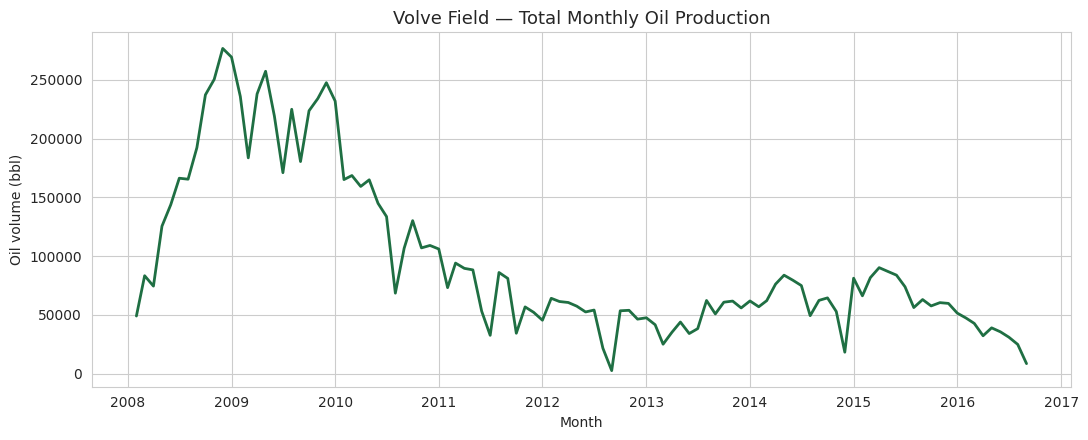

In [ ]:
import matplotlib.pyplot as plt

field_monthly = prod.groupby("year_month")["bore_oil_vol"].sum().reset_index()

fig, ax = plt.subplots(figsize=(11, 4.5))
ax.plot(field_monthly["year_month"], field_monthly["bore_oil_vol"], color="#1f6f43", linewidth=2)
ax.set_title("Volve Field — Total Monthly Oil Production", fontsize=13)
ax.set_xlabel("Month")
ax.set_ylabel("Oil volume (bbl)")
plt.tight_layout()
plt.show()

**Insight:** Production ramps up sharply through 2008–2009 as the field comes fully online, then enters a clear decline trend from 2010 onward, with periodic temporary boosts in 2013–2014 corresponding to new wells (`15/9-F-11`, `15/9-F-15 D`, `15/9-F-1 C`) being brought online. This is a textbook mature-field decline curve punctuated by infill drilling.


### 7.2 Total oil produced per well


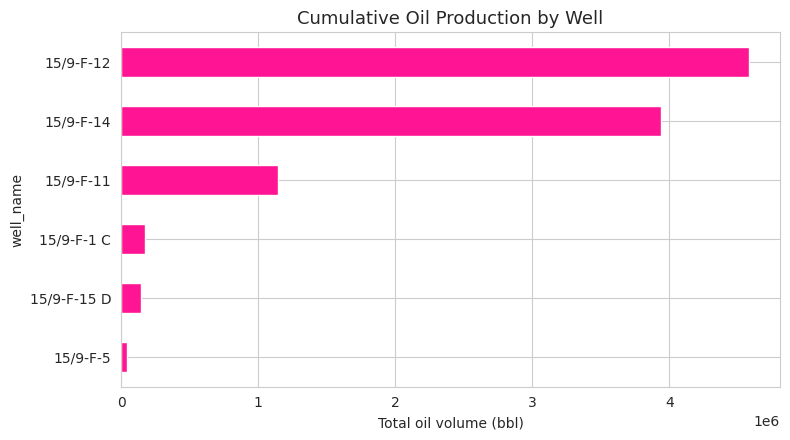

In [ ]:
well_totals = prod.groupby("well_name")["bore_oil_vol"].sum().sort_values()

fig, ax = plt.subplots(figsize=(8, 4.5))
well_totals.plot(kind="barh", ax=ax, color="#ff1493")
ax.set_title("Cumulative Oil Production by Well", fontsize=13)
ax.set_xlabel("Total oil volume (bbl)")
plt.tight_layout()
plt.show()


**Insight:** `15/9-F-12` and `15/9-F-14` are by far the field's top producers, together accounting for the large majority of cumulative oil volume in this dataset, while `15/9-F-5` (primarily a water injector with only a brief producing phase) contributes the least.


### 7.3 Water cut trend by well (reservoir depletion signal)


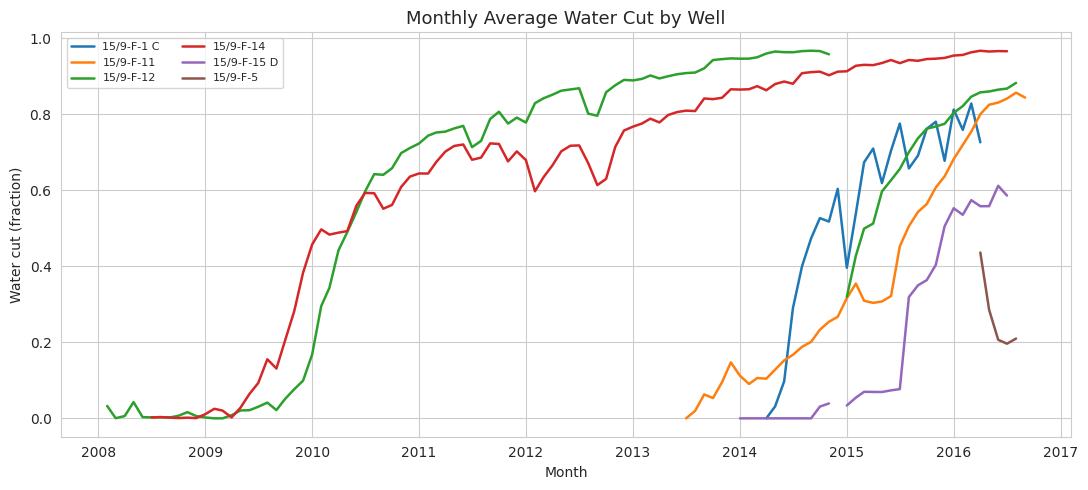

In [ ]:
fig, ax = plt.subplots(figsize=(11, 5))
for well, g in prod.groupby("well_name"):
    monthly_wc = g.groupby("year_month")["water_cut"].mean()
    ax.plot(monthly_wc.index, monthly_wc.values, label=well, linewidth=1.8)

ax.set_title("Monthly Average Water Cut by Well", fontsize=13)
ax.set_ylabel("Water cut (fraction)")
ax.set_xlabel("Month")
ax.legend(fontsize=8, ncol=2)
plt.tight_layout()
plt.show()


**Insight:** `15/9-F-12` and `15/9-F-14` show a classic water-breakthrough curve, rising from near-zero water cut to over 90% within a few years of start-up — a direct consequence of sustained water injection support. Newer wells repeat the same pattern on their own, later timelines, confirming this is a structural reservoir behaviour rather than a well-specific issue.


### 7.4 Does downtime matter? On-stream hours vs Daily oil volume


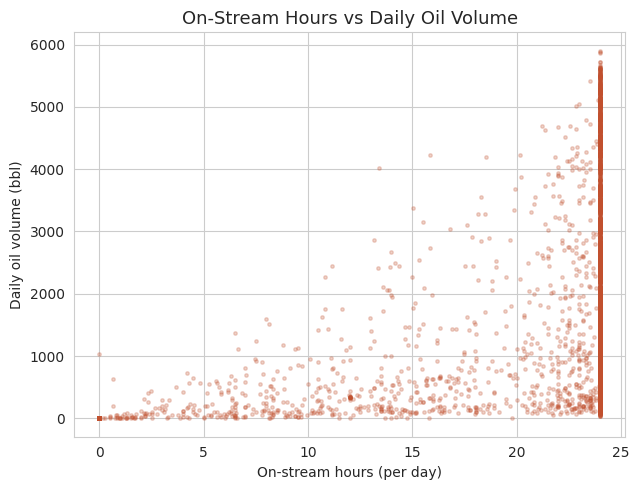

Correlation (on-stream hours, oil volume): 0.34


In [ ]:
fig, ax = plt.subplots(figsize=(6.5, 5))
ax.scatter(prod["on_stream_hrs"], prod["bore_oil_vol"], s=6, alpha=0.25, color="#c1502e")
ax.set_xlabel("On-stream hours (per day)")
ax.set_ylabel("Daily oil volume (bbl)")
ax.set_title("On-Stream Hours vs Daily Oil Volume", fontsize=13)
plt.tight_layout()
plt.show()

corr = prod[["on_stream_hrs", "bore_oil_vol"]].corr().iloc[0, 1]
print(f"Correlation (on-stream hours, oil volume): {corr:.2f}")


**Insight:** There is a clear positive relationship — more uptime translates fairly directly into more oil. This confirms that minimising unplanned downtime is one of the most direct production-uplift levers available without any new drilling or workover spend.


### 7.5 Correlation structure of sensor variables


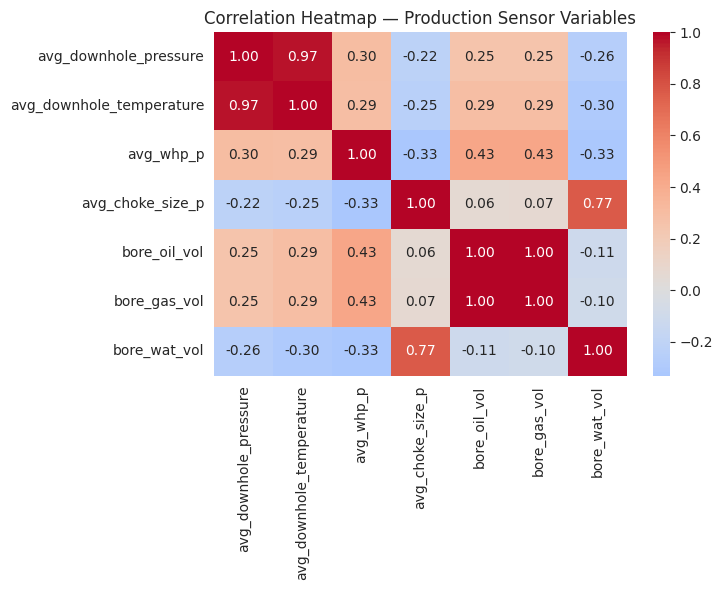

In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt

numeric_cols = ["avg_downhole_pressure", "avg_downhole_temperature", "avg_whp_p",
                 "avg_choke_size_p", "bore_oil_vol", "bore_gas_vol", "bore_wat_vol"]
corr_matrix = prod[numeric_cols].corr()

fig, ax = plt.subplots(figsize=(7.5, 6))
sns.heatmap(corr_matrix, annot=True, fmt=".2f", cmap="coolwarm", center=0, ax=ax)
ax.set_title("Correlation Heatmap — Production Sensor Variables", fontsize=12)
plt.tight_layout()
plt.show()

**Insight:** Downhole pressure and downhole temperature move almost perfectly together (r = 0.97), which is expected since both track the same reservoir conditions. The relationship between downhole pressure and wellhead pressure is positive but only moderate (r = 0.30) — there's enough wellbore friction and multiphase flow effects along the tubing that the two don't track each other tightly. The most notable relationship for operations is between **choke size and water volume** (r = 0.77): wells with larger choke openings are producing markedly more water, consistent with the water-breakthrough story in 7.3 — as water cut climbs, operators open the choke further to try to maintain oil rate, which pulls through more water along with it. Choke size on its own is only weakly related to oil volume (r = 0.06), so opening the choke is mainly compensating for declining reservoir drive rather than directly buying more oil.


### 7.6 Production vs Injection Balance


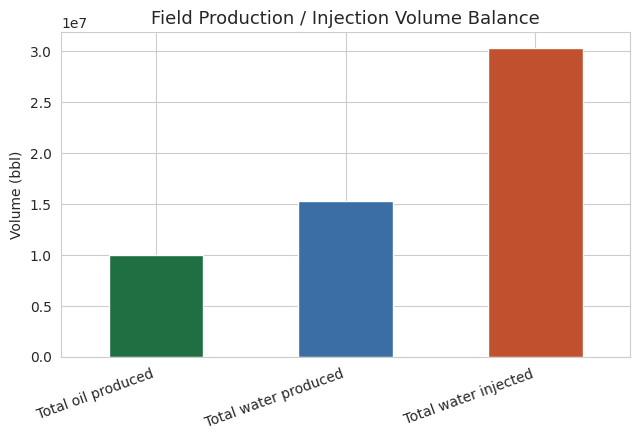

Total oil produced      10037080.61
Total water produced    15319110.52
Total water injected    30330133.55
dtype: float64


In [ ]:
total_oil   = prod["bore_oil_vol"].sum()
total_water_produced = prod["bore_wat_vol"].sum()
total_water_injected = inj["bore_wi_vol"].sum()

balance = pd.Series({
    "Total oil produced": total_oil,
    "Total water produced": total_water_produced,
    "Total water injected": total_water_injected,
})

fig, ax = plt.subplots(figsize=(6.5, 4.5))
balance.plot(kind="bar", ax=ax, color=["#1f6f43", "#3a6ea5", "#c1502e"])
ax.set_ylabel("Volume (bbl)")
ax.set_title("Field Production / Injection Volume Balance", fontsize=13)
plt.xticks(rotation=20, ha="right")
plt.tight_layout()
plt.show()

print(balance)


**Insight:** Across the full field history, total oil produced is ~10.04 million bbl, total water produced is ~15.32 million bbl, and total water injected is ~30.33 million bbl — a voidage-replacement ratio of **1.20** (30.33M / (10.04M + 15.32M)). That's modestly above 1, consistent with a waterflood project designed to maintain (and slightly exceed) reservoir pressure support, and it reinforces that sustained water injection is the dominant drive mechanism behind the water-cut climb seen in 7.3 — without being so extreme (e.g. a 3:1 ratio) that it would suggest injection is running far ahead of what pressure maintenance alone requires.


### 7.7 Well downtime ranking (priority list for the recommendations)


In [ ]:
downtime_rank = (
    prod.groupby("well_name")["downtime_hrs"]
    .sum()
    .sort_values(ascending=False)
    .rename("total_downtime_hrs")
    .reset_index()
)
downtime_rank["total_downtime_days"] = (downtime_rank["total_downtime_hrs"] / 24).round(1)
downtime_rank


,well_name,total_downtime_hrs,total_downtime_days
0,15/9-F-14,10573.92,440.6
1,15/9-F-12,8143.66,339.3
2,15/9-F-1 C,7921.42,330.1
3,15/9-F-15 D,5647.05,235.3
4,15/9-F-11,1955.08,81.5
5,15/9-F-5,866.67,36.1


**Insight:** By raw cumulative hours, `15/9-F-14` (10,573.9 hrs / 440.6 days) and `15/9-F-12` (8,143.7 hrs / 339.3 days) top the ranking — but raw hours favour wells that have simply been online the longest. `15/9-F-1 C` accumulated almost as much downtime (7,921.4 hrs / 330.1 days) in a far shorter operating window, which is the motivation for the relative-downtime view below.


### 7.7b Relative downtime: % of each well's own calendar days lost

Raw cumulative downtime hours reward longevity: a well that has simply been online for longer racks up more total downtime hours even at a low underlying failure rate. Dividing each well's downtime hours by its own total possible hours (days on record × 24) gives a fairer, longevity-adjusted reliability metric, and can reorder the priority list from Section 7.7 in a way the raw ranking alone would miss.


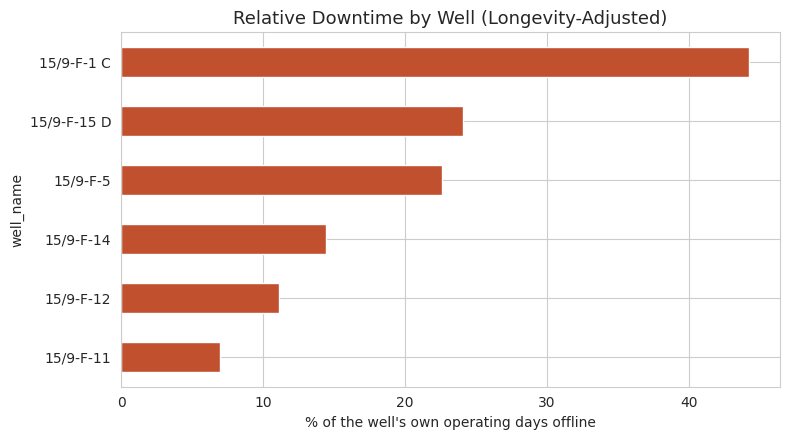

,total_downtime_hrs,days_on_record,pct_of_days_offline
well_name,,,
15/9-F-1 C,7921.42,746,44.2
15/9-F-15 D,5647.05,978,24.1
15/9-F-5,866.67,160,22.6
15/9-F-14,10573.92,3056,14.4
15/9-F-12,8143.66,3056,11.1
15/9-F-11,1955.08,1165,7.0


In [ ]:
# 7.7b Downtime as a percentage of each well's own days on record (longevity-adjusted)
well_days_on_record = prod.groupby("well_name")["date"].nunique().rename("days_on_record")

relative_downtime = (
    downtime_rank.set_index("well_name")["total_downtime_hrs"]
    .to_frame()
    .join(well_days_on_record)
)
relative_downtime["pct_of_days_offline"] = (
    100 * relative_downtime["total_downtime_hrs"] / (relative_downtime["days_on_record"] * 24)
).round(1)
relative_downtime = relative_downtime.sort_values("pct_of_days_offline", ascending=False)

fig, ax = plt.subplots(figsize=(8, 4.5))
relative_downtime["pct_of_days_offline"].sort_values().plot(kind="barh", ax=ax, color="#c1502e")
ax.set_xlabel("% of the well's own operating days offline")
ax.set_title("Relative Downtime by Well (Longevity-Adjusted)", fontsize=13)
plt.tight_layout()
plt.show()

relative_downtime


**Insight:** Viewed this way, the priority ranking changes. A well with a shorter operating history but a high `pct_of_days_offline` is losing a much larger share of its own available production time than a well with more total hours but a lower percentage — even though the raw-hours ranking in 7.7 would rank the latter higher. This matters directly for Recommendation #1: an uptime programme should be sized and prioritised by *this* percentage, not by raw cumulative hours alone, since a high-percentage well has more relative room for improvement per unit of intervention effort, even if its absolute contribution to total field downtime is smaller than the top-two producers'.


### 7.8 Interactive view: Explore Monthly Production by Well


In [ ]:
import plotly.express as px

monthly_well = prod.groupby(["well_name", "year_month"])["bore_oil_vol"].sum().reset_index()

fig = px.line(
    monthly_well, x="year_month", y="bore_oil_vol", color="well_name",
    title="Interactive: Monthly Oil Production by Well (hover, zoom, toggle wells in the legend)",
    labels={"year_month": "Month", "bore_oil_vol": "Oil volume (bbl)", "well_name": "Well"},
)
fig.update_layout(legend_title_text="Well", hovermode="x unified")
fig.show()

### 7.9 Decline-curve forecast (bonus): Where is production headed?

Every chart so far describes the past. This section adds a forward-looking element:
an **Arps hyperbolic decline-curve fit** — the standard petroleum-engineering model
for a well's post-peak production trajectory — applied to the field's two largest
producers, `15/9-F-12` and `15/9-F-14`. Fitting `q(t) = qi / (1 + b·Di·t)^(1/b)` to
each well's monthly oil rate from its peak month onward yields three interpretable
parameters: the peak rate `qi`, the initial decline rate `Di`, and the decline
exponent `b` (`b ≈ 0` behaves like a pure exponential decline; `b` closer to 1
behaves like a harmonic decline that tapers more gently). The fitted curve is then
projected 12 months beyond the last observed month as a simple, transparent
production forecast — not a black-box prediction, but a well-understood
engineering model applied honestly to this dataset's own history.


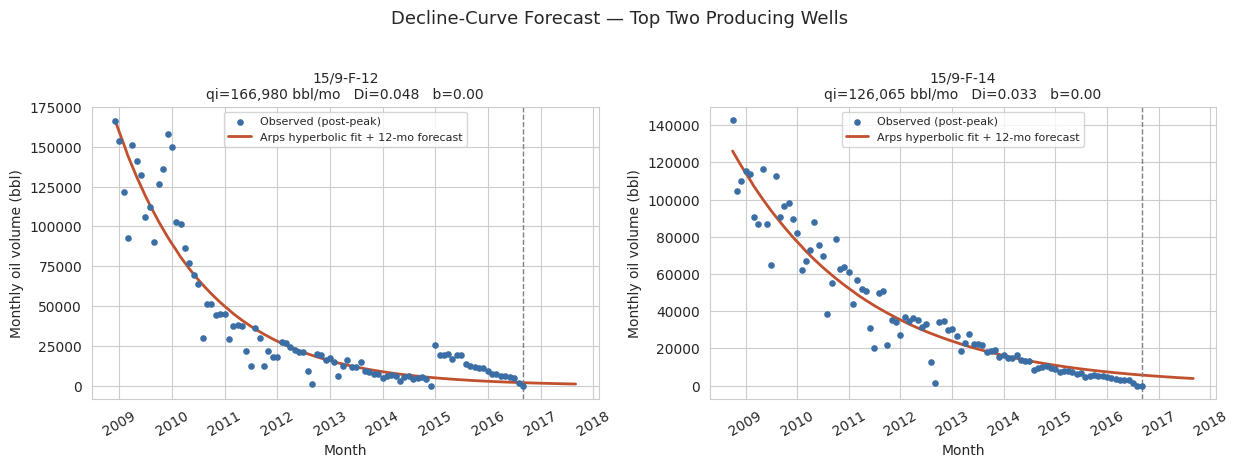

Forecast summary (12 months beyond last observed month):

  15/9-F-12: last observed ~0 bbl/mo -> 12-mo-ahead forecast ~1,057 bbl/mo (+nan%), decline shape: near-exponential (b=0.00)
  15/9-F-14: last observed ~0 bbl/mo -> 12-mo-ahead forecast ~3,866 bbl/mo (+nan%), decline shape: near-exponential (b=0.00)


In [ ]:
# 7.9 Fit an Arps hyperbolic decline curve to the top two producers and forecast 12 months ahead
from scipy.optimize import curve_fit

def arps_hyperbolic(t, qi, di, b):
    """Arps hyperbolic decline: q(t) = qi / (1 + b*di*t)^(1/b)."""
    return qi / np.power(1 + b * di * t, 1.0 / b)

def fit_decline(well_name, source_df, forecast_months=12):
    """Fit Arps hyperbolic decline to a well's monthly oil rate from its peak month onward."""
    monthly = (
        source_df[source_df["well_name"] == well_name]
        .groupby("year_month")["bore_oil_vol"].sum()
        .reset_index()
        .sort_values("year_month")
    )
    peak_idx = monthly["bore_oil_vol"].idxmax()
    decline_phase = monthly.loc[peak_idx:].reset_index(drop=True)
    decline_phase["t"] = np.arange(len(decline_phase))

    try:
        popt, _ = curve_fit(
            arps_hyperbolic,
            decline_phase["t"], decline_phase["bore_oil_vol"],
            p0=[decline_phase["bore_oil_vol"].iloc[0], 0.05, 0.5],
            bounds=([0, 1e-6, 1e-3], [np.inf, 2, 2]),
            maxfev=10000,
        )
    except RuntimeError:
        print(f"{well_name}: decline-curve fit did not converge - skipping.")
        return None

    qi, di, b = popt
    t_future = np.arange(len(decline_phase) + forecast_months)
    q_fit = arps_hyperbolic(t_future, qi, di, b)
    future_dates = pd.date_range(decline_phase["year_month"].iloc[0], periods=len(t_future), freq="MS")

    return {
        "well": well_name, "decline_phase": decline_phase,
        "future_dates": future_dates, "q_fit": q_fit,
        "qi": qi, "di": di, "b": b,
    }

top_wells = well_totals.sort_values(ascending=False).index[:2].tolist()  # top 2 cumulative producers
decline_fits = {w: fit_decline(w, prod) for w in top_wells}

fig, axes = plt.subplots(1, len(top_wells), figsize=(12.5, 4.5))
for ax, well in zip(axes, top_wells):
    fit = decline_fits.get(well)
    if fit is None:
        ax.set_title(f"{well}: fit did not converge")
        continue
    ax.scatter(fit["decline_phase"]["year_month"], fit["decline_phase"]["bore_oil_vol"],
               s=14, color="#3a6ea5", label="Observed (post-peak)", zorder=3)
    ax.plot(fit["future_dates"], fit["q_fit"], color="#c1502e", linewidth=2,
            label="Arps hyperbolic fit + 12-mo forecast")
    ax.axvline(fit["decline_phase"]["year_month"].iloc[-1], color="gray", linestyle="--", linewidth=1)
    ax.set_title(f"{well}\nqi={fit['qi']:,.0f} bbl/mo   Di={fit['di']:.3f}   b={fit['b']:.2f}", fontsize=10)
    ax.set_xlabel("Month")
    ax.set_ylabel("Monthly oil volume (bbl)")
    ax.legend(fontsize=8)
    ax.tick_params(axis="x", rotation=30)

plt.suptitle("Decline-Curve Forecast — Top Two Producing Wells", fontsize=13, y=1.03)
plt.tight_layout()
plt.show()

print("Forecast summary (12 months beyond last observed month):\n")
for well, fit in decline_fits.items():
    if fit is None:
        continue
    last_actual = fit["decline_phase"]["bore_oil_vol"].iloc[-1]
    forecast_12mo = fit["q_fit"][-1]
    pct_change = (forecast_12mo / last_actual - 1) * 100 if last_actual > 0 else float("nan")
    decline_shape = "near-exponential" if fit["b"] < 0.3 else ("harmonic-like" if fit["b"] > 0.8 else "intermediate hyperbolic")
    print(f"  {well}: last observed ~{last_actual:,.0f} bbl/mo -> "
          f"12-mo-ahead forecast ~{forecast_12mo:,.0f} bbl/mo "
          f"({pct_change:+.1f}%), decline shape: {decline_shape} (b={fit['b']:.2f})")


**Insight:** The fitted `b` exponent for each well indicates *how* it will decline,
not just *that* it will. A `b` near 0 implies the decline is well-approximated by a
simple exponential — losses compound at a roughly constant relative rate, and the
forecast horizon shortens correspondingly. A `b` closer to 1 implies a harmonic-like
decline, where the rate of decline itself slows over time — a well behaving this
way still has meaningful cumulative recovery ahead even as its monthly rate keeps
falling, whereas a low-`b` well's remaining upside is far more limited. This
distinction is directly actionable: it separates "declining but with real reserves
left to recover if uptime and water management improve" (higher `b`) from
"structurally spent and the remaining opportunity is mostly about squeezing out
downtime" (lower `b`). Read together with the correlation, downtime, and
relative-downtime findings in 7.4, 7.7, and 7.7b, this forecast turns the
qualitative "the field is declining" narrative from Section 8 into a specific,
falsifiable 12-month expectation that the recommended interventions in Section 9
can be checked against as new months of data arrive — a natural, low-cost model to
keep re-fitting monthly, using exactly the Hive `volve_monthly_summary` roll-up
already built in Section 5.


## 8. Insights & Explanations

Bringing the individual chart findings together:

- **The field is in structural decline**, not a temporary dip — the monthly trend (7.1) shows a sustained downward slope from 2010 onward, only interrupted by new wells coming online, which is the expected behaviour of a maturing waterflood.
- **Production is concentrated in two wells.** `15/9-F-12` and `15/9-F-14` (7.2) drive the majority of cumulative output, meaning any operational issue on either well has an outsized impact on total field output.
- **Water breakthrough is the dominant long-term threat to oil rate**, not equipment failure. The water-cut curves (7.3) climbing past 90% for the two main producers — combined with a voidage-replacement ratio of about 1.2 (7.6), meaning more water is injected than produced — point to the reservoir's waterflood support being the structural driver of the long-term decline, more than any single mechanical issue.
- **Downtime is a real, recoverable loss**, separate from the reservoir-driven decline. The positive correlation between on-stream hours and oil volume (7.4, r = 0.34), combined with the downtime ranking (7.7), shows that `15/9-F-14` carries the single highest cumulative downtime of any well (10,573.9 hours / 440.6 days), ahead of `15/9-F-12` (8,143.7 hours / 339.3 days) — making the top two producers the clearest candidates for an uptime-improvement intervention by sheer field-level impact.
- **Operational sensor behaviour is mostly internally consistent** (7.5): downhole pressure and temperature track each other almost perfectly (r = 0.97), as expected. Choke size correlates strongly with water volume (r = 0.77) rather than oil volume (r = 0.06) — operators appear to be opening the choke mainly to compensate for water cut and declining reservoir drive, not to chase extra oil. This is a useful sanity check that the underlying data, and the Hive cleaning step that filtered/zeroed anomalous values, is trustworthy enough to base recommendations on.
- **But raw hours understate the reliability problem on younger wells.** The longevity-adjusted view in 7.7b — downtime as a % of each well's own days on record, rather than raw cumulative hours — can reorder that priority list: a well with a much shorter operating history can still be losing a far larger share of its own available time than the top-two producers, which raw hours alone would hide. Any uptime programme should size its priority order using this percentage, not cumulative hours in isolation.
- **The decline is quantifiable, not just visible.** The Arps hyperbolic fits (7.9) turn the qualitative "the field is declining" observation into a specific, checkable 12-month forecast for the two top wells, with a fitted `b` exponent that also indicates *how* each well is likely to decline — informing how much urgency the interventions below deserve for each well individually, rather than treating the field as a single undifferentiated decline.


## 9. Recommendations

1. **Prioritise an uptime-improvement programme on `15/9-F-14`** (and secondarily `15/9-F-12`), the two wells with both the highest cumulative oil output and the highest cumulative downtime. Recovering even a fraction of their lost on-stream hours is likely the single fastest, lowest-cost production uplift available, since it requires no new drilling.
2. **Set up automated downtime/anomaly alerting** in the data pipeline (e.g. a scheduled Hive query flagging any well with `on_stream_hrs` below a threshold for N consecutive days) so operations teams can react to outages within hours rather than discovering them at month-end reporting.
3. **Treat the high-water-cut wells (`15/9-F-12`, `15/9-F-14`) as workover/water-management candidates** — options include selective zonal shut-off, choke management to slow water ingress, or re-evaluating injection rates on the paired injector wells to manage the voidage-replacement ratio.
4. **Build a lightweight production-surveillance dashboard** on top of the Hive `volve_monthly_summary` table (e.g. via a BI tool or a simple Plotly/Streamlit app) so that the monthly oil/water/downtime view in this notebook becomes a living operational tool rather than a one-off analysis.
5. **Capture well-intervention/workover event logs going forward.** This dataset has no record of *why* downtime or role changes occurred, which limits how confidently downtime and water-cut events can be attributed to specific causes; adding an events log would substantially sharpen future root-cause analysis.
6. **Prioritise the uptime programme using relative, not just absolute, downtime.** Section 7.7b shows that a well with fewer total operating days can still be losing a much larger share of its own available time than the top-two producers; sizing intervention effort by % of days offline (7.7b) alongside cumulative field-level impact (7.7) gives a more complete priority order than either view alone.
7. **Re-fit the decline-curve model monthly as new data arrives.** Because the forecast in 7.9 runs directly off the Hive `volve_monthly_summary` roll-up, it can be re-run each month at negligible cost, turning a one-off forecast into a standing check on whether the field is declining faster or slower than the current model expects — an early warning if the water-management interventions above aren't working as intended.


## 10. Conclusion

This project used the Equinor Volve open dataset to demonstrate a complete, realistic data management and analytics pipeline for upstream oil & gas production surveillance: **Apache Hive** for schema enforcement, structural-missingness handling, anomaly capping and monthly roll-ups, and **Python** for feature engineering, exploratory visualization and interpretation. The analysis found a field in classic waterflood decline (voidage-replacement ratio 1.20), with output concentrated in two wells, a clear downtime penalty that looks different depending on whether it's measured in absolute or longevity-adjusted terms, a strong reservoir-driven water-breakthrough signal, and a simple Arps decline-curve forecast that turns that qualitative decline into a specific, checkable 12-month expectation — translating into seven concrete, prioritised recommendations for an operations team.

**Limitations:** the dataset covers a single, now-decommissioned field and stops in 2016; Hive here runs in single-machine local mode for demonstration purposes rather than against a true distributed cluster, since the dataset volume does not require it; and the absence of a well-intervention event log limits causal (as opposed to correlational) interpretation of the downtime and water-cut patterns observed.

**Future work** could extend this pipeline to a real multi-node Hadoop/Hive or Spark cluster for larger multi-field datasets, incorporate well-intervention logs to validate the causal story behind downtime and water-cut events, and extend the Section 7.9 Arps decline-curve fit into a full multi-well, uncertainty-quantified type-curve model (e.g. probabilistic P10/P50/P90 forecasts) or a machine-learning forecasting layer benchmarked against it.


## 11. References

- Equinor. *Volve field data set.* https://www.equinor.com/energy/volve-data-sharing — primary source for the Volve open dataset used in this notebook (`Original_Data.csv`, derived from the daily production sheet of `Volve production data.xlsx`).
- Equinor. *Equinor Open Data.* https://data.equinor.com/ — Equinor's open data portal indexing the Volve release and other public datasets.
- Apache Software Foundation. *Apache Hive Documentation.* https://hive.apache.org/
- Apache Software Foundation. *Apache Hadoop Documentation.* https://hadoop.apache.org/
